# 04 — Building Model, BLE Model, and the Particle Filter

This notebook covers the heart of the system:

- **M2 — building model** (`building.py`): the walkable corridors, door positions,
  beacon positions, and staircase zones.
- **M4 — BLE observation model** (`ble.py`): turning an RSSI reading into a weight
  for each particle.
- **M5 — particle filter** (`particle_filter.py`): fusing motion + map + BLE +
  floor transitions, built up in four sub-steps (5a -> 5d).

Everything is demonstrated on Run 1, using its calibrated start conditions from
`preprocessing.RUN_START`.

In [1]:
import sys
sys.path.append("../src")
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import preprocessing
import imu
import building
import ble
import particle_filter as pf
import visualization as viz

RAW = "../data/raw"
REF = "../assignment/Paths_references.xlsx"

run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])

## M2 — The building model

Each floor is modelled as one main corridor plus a short east stub, described by a
centre-line poly-line with a half-width: a point is *walkable* if it lies within
that half-width. The world frame is metric with the origin at the west staircase
(x = east, y = north) and a separate floor index (0 = lower, 1 = upper). Doors sit
on the corridor centre-line; beacons are the six marked on the path sketches; floor
changes are allowed only inside the two staircase zones.

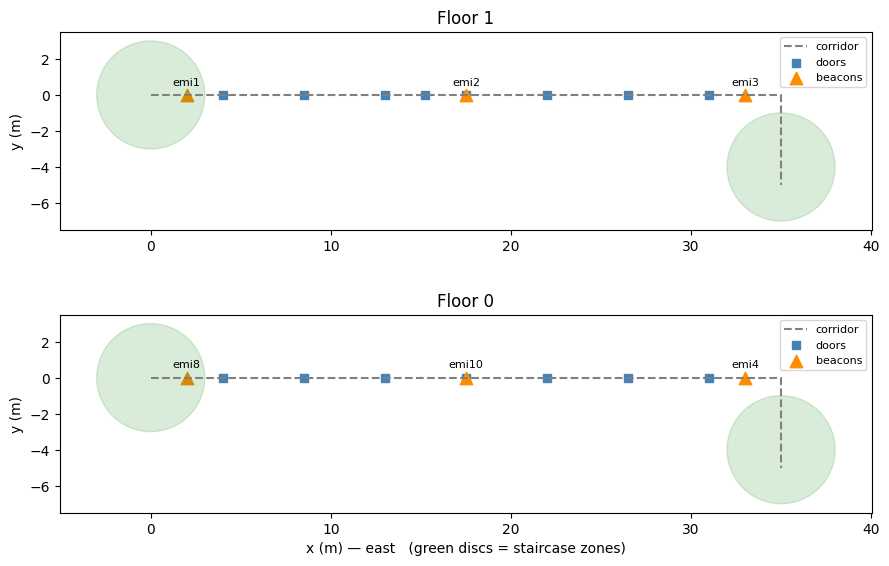

In [2]:
doors = building.door_positions()
beacons = building.beacon_positions()

fig, axes = plt.subplots(2, 1, figsize=(9, 6))
for floor_index, ax in zip([1, 0], axes):
    polyline = building.corridor_polyline(floor_index)
    ax.plot([p[0] for p in polyline], [p[1] for p in polyline],
            "--", color="gray", label="corridor")

    floor_doors = [v for k, v in doors.items() if k[0] == floor_index]
    ax.scatter([d[0] for d in floor_doors], [d[1] for d in floor_doors],
               marker="s", s=30, color="steelblue", label="doors")

    floor_beacons = {n: p for n, p in beacons.items() if p[2] == floor_index}
    ax.scatter([p[0] for p in floor_beacons.values()],
               [p[1] for p in floor_beacons.values()],
               marker="^", s=80, color="darkorange", label="beacons")
    for name, p in floor_beacons.items():
        ax.annotate(name.replace("arrive_", ""), (p[0], p[1]),
                    textcoords="offset points", xytext=(0, 7), fontsize=8, ha="center")

    for cx, cy in [building.WEST_STAIRCASE, building.EAST_STAIRCASE]:
        ax.add_patch(plt.Circle((cx, cy), building.STAIRCASE_RADIUS_M,
                                color="green", alpha=0.15))

    ax.set_title("Floor %d" % floor_index)
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("x (m) — east   (green discs = staircase zones)")
plt.tight_layout()
plt.show()

A couple of quick validity checks: a point on the corridor centre-line is walkable,
a point well off it is not, and the staircase zones sit at the two ends.

In [3]:
print("is_walkable(10, 0.0, 0)  :", building.is_walkable(10, 0.0, 0))   # on the corridor
print("is_walkable(10, 3.0, 0)  :", building.is_walkable(10, 3.0, 0))   # through a wall
print("can_change_floor(0, 0)   :", building.can_change_floor(0, 0))    # west staircase
print("can_change_floor(17, 0)  :", building.can_change_floor(17, 0))   # mid-corridor

is_walkable(10, 0.0, 0)  : True
is_walkable(10, 3.0, 0)  : False
can_change_floor(0, 0)   : True
can_change_floor(17, 0)  : False


## M4 — The BLE observation model

A beacon close to the phone is heard strongly; a distant one weakly. The
log-distance path-loss model captures this, and for one reading we weight each
particle by how well its position explains the observed RSSI (a Gaussian on the
RSSI residual). "Strong signals weighted more" falls out for free: a strong RSSI is
only explained by particles close to the beacon (a tight, informative peak), while
a weak RSSI is explained by a large far region (barely informative).

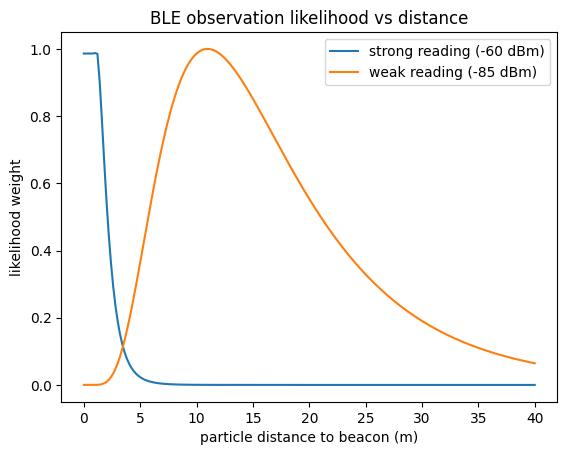

In [4]:
# Weight of a particle vs its distance to one beacon, for a strong and a weak reading.
distance = np.linspace(0, 40, 200)
beacon_position = (0.0, 0.0, 0)   # beacon at the origin, floor 0
zeros = np.zeros_like(distance)

for observed_rssi, label in [(-60.0, "strong reading (-60 dBm)"),
                             (-85.0, "weak reading (-85 dBm)")]:
    weights = ble.rssi_likelihood(distance, zeros, zeros.astype(int),
                                  beacon_position, observed_rssi)
    plt.plot(distance, weights, label=label)

plt.xlabel("particle distance to beacon (m)")
plt.ylabel("likelihood weight")
plt.title("BLE observation likelihood vs distance")
plt.legend()
plt.show()

## M5 — The particle filter, built in sub-steps

State per particle: position `(x, y)` and, from 5d, a `floor`. We add one
ingredient at a time so each is easy to check.

### 5a — Motion only

Move a cloud of particles using the motion table; no correction, so the cloud just
spreads. Its mean tracks the dead-reckoning path, and the growing rings show the
motion uncertainty accumulating.

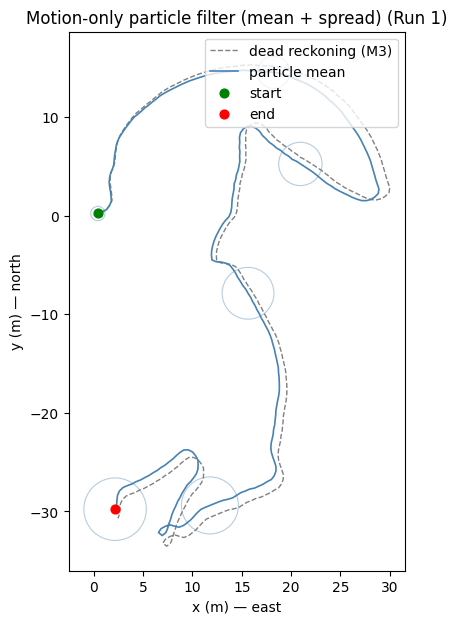

In [5]:
dead_reckoning = imu.dead_reckoning(motion, start=cfg["start"])
traj_5a, spread_5a = pf.run_motion_only(run, motion, start=cfg["start"], seed=0)

viz.plot_particle_cloud(traj_5a, spread_5a, dead_reckoning=dead_reckoning, run_id=1)
plt.show()

### 5b — Add building constraints

Weight particles by how walkable they are (a soft wall) and resample. The estimate
is pulled onto the corridor, but with no absolute reference the map alone cannot
fix heading drift — it only damps the excursion (decision D9).

resamples: 217


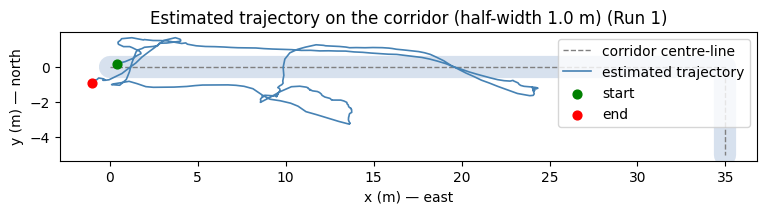

In [6]:
traj_5b, spread_5b, n_resamples_5b = pf.run_with_constraints(
    run, motion, start=cfg["start"], building=building, floor=0, seed=0)
print("resamples:", n_resamples_5b)

viz.plot_trajectory_on_corridor(traj_5b, building.corridor_polyline(0),
                                building.CORRIDOR_HALF_WIDTH_M, run_id=1)
plt.show()

### 5c — Add the BLE correction

Each BLE reading multiplies in the observation likelihood, giving the absolute
reference the map lacked. Beacons are marked as triangles.

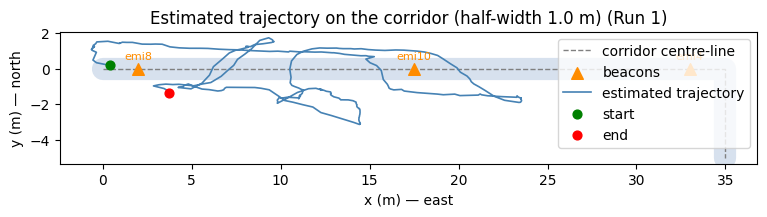

In [7]:
traj_5c, spread_5c, n_resamples_5c = pf.run_with_ble(
    run, motion, start=cfg["start"], building=building, ble=ble, floor=0, seed=0)

floor0_beacons = {n: p for n, p in building.beacon_positions().items() if p[2] == 0}
viz.plot_trajectory_on_corridor(traj_5c, building.corridor_polyline(0),
                                building.CORRIDOR_HALF_WIDTH_M,
                                beacons=floor0_beacons, run_id=1)
plt.show()

### 5d — Add floor transitions (the full filter)

Each particle now carries a floor and may switch floor only inside a staircase
zone; the BLE update keeps whichever particles are on the floor whose beacons match
the reading. `run_filter` is the complete fusion.

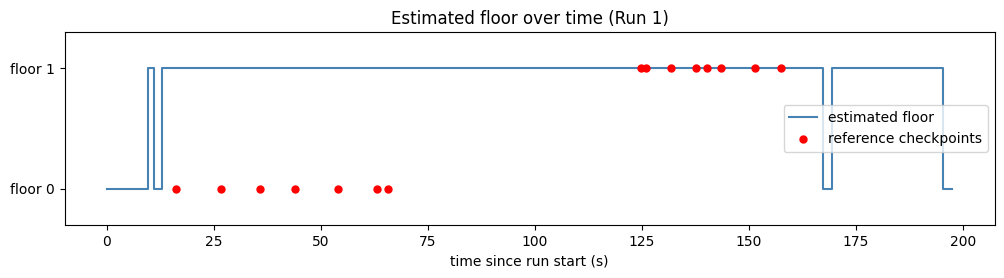

In [8]:
import evaluation
reference = evaluation.load_reference(1, reference_file=REF)

traj_5d, spread_5d, n_resamples_5d = pf.run_filter(
    run, motion, start=cfg["start"], floor=cfg["floor"],
    building=building, ble=ble, seed=0)

viz.plot_floor_over_time(traj_5d, reference, run_id=1)
plt.show()

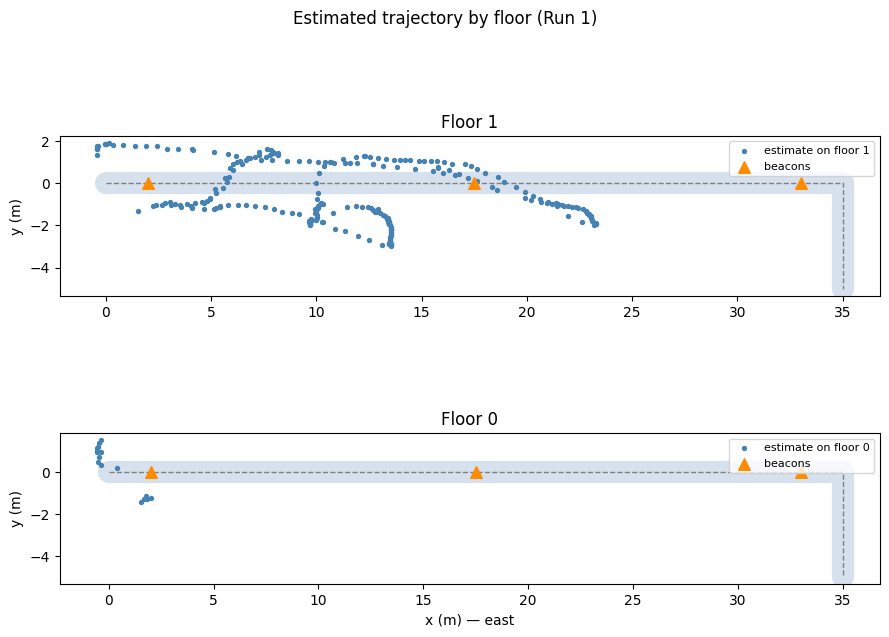

In [9]:
viz.plot_trajectory_two_floors(traj_5d, building.corridor_polyline(0),
                               building.CORRIDOR_HALF_WIDTH_M,
                               beacons=building.beacon_positions(), run_id=1)
plt.show()

## Honest limitations

- The **map alone cannot correct heading drift** (5b): it damps the excursion but
  needs an absolute reference (D9).
- **Floor determination is imperfect** (5d): position drift can leave the cloud
  short of a staircase zone, floor "locks" between staircases, and BLE is coarse
  (~50% nearest-beacon). Floor accuracy averages ~0.66 across the runs (D12).

These are realistic for a coarse indoor system — exactly what the assignment says
to expect. They are quantified and discussed in **05 — Evaluation** (Milestone M6).